# ONDOUSDC Depth Concentration and Entropy

This notebook studies how liquidity is distributed across the top of the book.
The question is whether liquidity is clustered at one or two levels, or spread across the ladder.

The target is future absolute return, because concentration is a sweepability and magnitude feature more than a directional signal.

Questions:

- how concentrated are bid and ask queues across the top `L` levels?
- does lower entropy or higher touch-share line up with larger future moves?
- does concentration still add anything once `flow` and `top` are already in the model?

## Metric Definitions

For one side of the book and a chosen depth `L`, let `qty_i` be the resting quantity at level `i`.

- `share_i = qty_i / sum(qty_1..qty_L)`
- `entropy = -sum(share_i * log(share_i))`
- `normalized_entropy = entropy / log(L)`
- `concentration = 1 - normalized_entropy`
- `hhi = sum(share_i^2)`
- `effective_levels = exp(entropy)`
- `touch_share_2 = share_1 + share_2`

Interpretation:

- lower entropy means more concentrated liquidity
- higher concentration means more concentrated liquidity
- higher HHI means more concentrated liquidity
- lower effective levels means more concentrated liquidity
- higher touch-share means more liquidity sits near the touch

Why this notebook uses future return magnitude:

- `future_return` is the log-mid move from the current trade timestamp to `horizon` seconds ahead, built with `build_clock_time_delta(...)`
- `future_abs_return_bps = abs(future_return) * 1e4`
- the regression checks compare concentration features against `future_abs_return_bps`, so the prediction target is movement size rather than signed direction

The main summary tables treat the average of bid and ask metrics as the primary signal.
The bid/ask gap is kept as a secondary diagnostic.

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def load_notebook_utils(start: Path | None = None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        utils_path = candidate / 'notebooks' / 'notebook_utils.py'
        if utils_path.is_file():
            spec = importlib.util.spec_from_file_location('notebook_utils', utils_path)
            if spec is None or spec.loader is None:
                raise ImportError(f'Could not load notebook utilities from {utils_path}')
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            return module
    raise FileNotFoundError('Could not locate notebooks/notebook_utils.py')


notebook_utils = load_notebook_utils()
PROJECT_ROOT = notebook_utils.bootstrap_backtester_path()

from stats.features import make_trade_frame
from stats.notebook import load_orderflow_day
from stats.tables import get_or_build_book_levels_table

print(f'PROJECT_ROOT = {PROJECT_ROOT}')

PROJECT_ROOT = /Users/hoangdeveloper/PycharmProjects/exchange-data-backtester


In [2]:
EXCHANGE = 'binance'
SYMBOL = 'ONDOUSDC'

TRAIN_DAYS = ['20260226', '20260227']
VALID_DAY = '20260228'
STRESS_DAY = '20260301'
DAYS = [*TRAIN_DAYS, VALID_DAY, STRESS_DAY]

HORIZONS = ['1s', '2s', '3s']
REPLAY_ON_GAP = 'skip-segment'

FLOW_SIGNAL_T = 10
FLOW_A = 0.0

BOOK_LEVELS = [2, 5, 10, 15]
MAX_BOOK_LEVEL = max(BOOK_LEVELS)

BOOK_QTY_COLS = [f'{side}{level}_qty' for level in range(1, MAX_BOOK_LEVEL + 1) for side in ('bid', 'ask')]

In [3]:
def split_days(split_name: str) -> list[str]:
    if split_name == 'train':
        return TRAIN_DAYS
    if split_name == 'valid':
        return [VALID_DAY]
    if split_name == 'stress':
        return [STRESS_DAY]
    raise ValueError(split_name)


def safe_corr(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) <= 1 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan
    pearson = float(np.corrcoef(x, y)[0, 1])
    spearman = float(np.corrcoef(pd.Series(x).rank(method='average'), pd.Series(y).rank(method='average'))[0, 1])
    return pearson, spearman


def compute_side_concentration(frame: pd.DataFrame, *, side: str, levels: int) -> pd.DataFrame:
    qty_cols = [f'{side}{k}_qty' for k in range(1, levels + 1)]
    missing = [name for name in qty_cols if name not in frame.columns]
    if missing:
        raise KeyError(f'Missing {side} depth columns for levels={levels}: {missing[:8]}')

    qty = frame[qty_cols].to_numpy(dtype=float)
    qty = np.nan_to_num(qty, nan=0.0)
    total = qty.sum(axis=1)
    valid = total > 0

    shares = np.divide(
        qty,
        total[:, None],
        out=np.full_like(qty, np.nan, dtype=float),
        where=valid[:, None],
    )

    positive = np.isfinite(shares) & (shares > 0)
    log_shares = np.zeros_like(shares, dtype=float)
    log_shares[positive] = np.log(shares[positive])

    entropy_raw = -np.sum(np.where(positive, shares * log_shares, 0.0), axis=1)
    entropy_raw[~valid] = np.nan

    entropy_norm = np.divide(
        entropy_raw,
        np.log(levels),
        out=np.full_like(entropy_raw, np.nan, dtype=float),
        where=np.isfinite(entropy_raw),
    )
    hhi = np.sum(np.where(np.isfinite(shares), shares ** 2, 0.0), axis=1)
    hhi[~valid] = np.nan

    effective_levels = np.exp(entropy_raw)
    effective_levels[~valid] = np.nan

    touch_share_2 = np.nansum(shares[:, : min(2, levels)], axis=1)
    touch_share_2[~valid] = np.nan

    weights = np.arange(1, levels + 1, dtype=float)
    center_of_mass = np.nansum(np.where(np.isfinite(shares), shares, 0.0) * weights[None, :], axis=1)
    center_of_mass[~valid] = np.nan

    return pd.DataFrame(
        {
            f'{side}_entropy_{levels}': entropy_raw,
            f'{side}_entropy_norm_{levels}': entropy_norm,
            f'{side}_concentration_{levels}': 1.0 - entropy_norm,
            f'{side}_hhi_{levels}': hhi,
            f'{side}_effective_levels_{levels}': effective_levels,
            f'{side}_touch_share_2_{levels}': touch_share_2,
            f'{side}_center_of_mass_{levels}': center_of_mass,
        },
        index=frame.index,
    )


def add_concentration_metrics(frame: pd.DataFrame, levels_list: list[int] = BOOK_LEVELS) -> pd.DataFrame:
    out = frame.copy()
    for levels in levels_list:
        bid = compute_side_concentration(out, side='bid', levels=levels)
        ask = compute_side_concentration(out, side='ask', levels=levels)
        out = pd.concat([out, bid, ask], axis=1)
        out[f'book_entropy_mean_{levels}'] = 0.5 * (
            out[f'bid_entropy_norm_{levels}'] + out[f'ask_entropy_norm_{levels}']
        )
        out[f'book_concentration_mean_{levels}'] = 1.0 - out[f'book_entropy_mean_{levels}']
        out[f'book_hhi_mean_{levels}'] = 0.5 * (out[f'bid_hhi_{levels}'] + out[f'ask_hhi_{levels}'])
        out[f'book_effective_levels_mean_{levels}'] = 0.5 * (
            out[f'bid_effective_levels_{levels}'] + out[f'ask_effective_levels_{levels}']
        )
        out[f'book_touch_share_2_mean_{levels}'] = 0.5 * (
            out[f'bid_touch_share_2_{levels}'] + out[f'ask_touch_share_2_{levels}']
        )
        out[f'book_entropy_gap_{levels}'] = out[f'ask_entropy_norm_{levels}'] - out[f'bid_entropy_norm_{levels}']
    return out


def build_feature_frame(trade_frame: pd.DataFrame, book_levels: pd.DataFrame, horizon: str) -> pd.DataFrame:
    trade_frame = trade_frame.sort_values('ts').reset_index(drop=True).copy()
    book_levels = book_levels.sort_values('ts').reset_index(drop=True).copy()
    book_mid_frame = book_levels[['ts', 'log_mid']].copy()

    frame = trade_frame[['ts']].copy()
    frame['trade_flow_imbalance'] = notebook_utils.build_imbalance_for_signal(
        trade_frame,
        signal_T=FLOW_SIGNAL_T,
        a=FLOW_A,
    )

    merge_cols = ['ts', 'mid', 'spread', 'top_imbalance', 'log_mid', *BOOK_QTY_COLS]
    frame = pd.merge_asof(
        frame.sort_values('ts'),
        book_levels[merge_cols].sort_values('ts'),
        on='ts',
        direction='backward',
    )

    frame = add_concentration_metrics(frame)
    frame['future_return'] = notebook_utils.build_clock_time_delta(trade_frame, book_mid_frame, horizon)
    frame['future_abs_return_bps'] = np.abs(frame['future_return']) * 1e4
    frame['horizon'] = horizon
    return frame.dropna(subset=['future_return']).reset_index(drop=True)


def get_split_frame(day_records: list[dict], horizon: str, split_name: str) -> pd.DataFrame:
    days = set(split_days(split_name))
    frames = [record['frames'][horizon] for record in day_records if record['day'] in days]
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True).copy()


def fit_ols_beta(frame: pd.DataFrame, feature_cols: list[str], target_col: str = 'future_abs_return_bps') -> np.ndarray:
    sub = frame[[target_col, *feature_cols]].dropna().copy()
    x = np.column_stack([np.ones(len(sub), dtype=float), sub[feature_cols].to_numpy(dtype=float)])
    y = sub[target_col].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(x, y, rcond=None)
    return beta


def ols_predict(frame: pd.DataFrame, feature_cols: list[str], beta: np.ndarray, target_col: str = 'future_abs_return_bps') -> tuple[pd.DataFrame, np.ndarray]:
    sub = frame[[target_col, *feature_cols]].dropna().copy()
    x = np.column_stack([np.ones(len(sub), dtype=float), sub[feature_cols].to_numpy(dtype=float)])
    pred = x @ beta
    return sub, pred


def regression_metrics(y_true: np.ndarray, pred: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(y_true) & np.isfinite(pred)
    if not mask.any():
        return {'n': 0, 'r2': np.nan, 'pearson': np.nan, 'spearman': np.nan, 'mae': np.nan}
    y = y_true[mask]
    p = pred[mask]
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - p) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    pearson, spearman = safe_corr(y, p)
    mae = float(np.mean(np.abs(y - p)))
    return {'n': int(len(y)), 'r2': float(r2), 'pearson': pearson, 'spearman': spearman, 'mae': mae}


def summarize_feature(frame: pd.DataFrame, feature_col: str, target_col: str = 'future_abs_return_bps') -> pd.Series:
    sub = frame[[feature_col, target_col]].dropna().copy()
    x = sub[feature_col].to_numpy(dtype=float)
    y = sub[target_col].to_numpy(dtype=float)
    pearson, spearman = safe_corr(x, y)
    return pd.Series(
        {
            'n': int(len(sub)),
            'feature_mean': float(np.mean(x)) if len(sub) else np.nan,
            'feature_median': float(np.median(x)) if len(sub) else np.nan,
            'target_mean_bps': float(np.mean(y)) if len(sub) else np.nan,
            'pearson': pearson,
            'spearman': spearman,
        }
    )

In [4]:
day_records = []
summary_rows = []

for day in DAYS:
    dataset, trades, top, replay_info = load_orderflow_day(
        exchange=EXCHANGE,
        symbol=SYMBOL,
        day=day,
        replay_on_gap=REPLAY_ON_GAP,
    )
    trade_frame = make_trade_frame(trades, top, include_log_mid=True, include_trade_idx=True)
    trade_frame = trade_frame.sort_values('ts').reset_index(drop=True).copy()
    trade_frame['day'] = day

    book_levels = get_or_build_book_levels_table(
        dataset,
        top_n=MAX_BOOK_LEVEL,
        on_gap=REPLAY_ON_GAP,
        show_progress=False,
    )
    book_levels = book_levels.sort_values('ts').reset_index(drop=True).copy()
    book_levels['mid'] = (book_levels['bid1_price'] + book_levels['ask1_price']) / 2.0
    book_levels['spread'] = book_levels['ask1_price'] - book_levels['bid1_price']
    book_levels['top_imbalance'] = (
        book_levels['bid1_qty'] - book_levels['ask1_qty']
    ) / (book_levels['bid1_qty'] + book_levels['ask1_qty'])
    book_levels['log_mid'] = np.log(book_levels['mid'])

    frames = {}
    for horizon in HORIZONS:
        frames[horizon] = build_feature_frame(trade_frame, book_levels, horizon)

    day_records.append(
        {
            'day': day,
            'dataset': dataset,
            'trade_frame': trade_frame,
            'book_levels': book_levels,
            'frames': frames,
            'replay_info': replay_info,
        }
    )

    summary_rows.append(
        {
            'day': day,
            'trade_rows': len(trade_frame),
            'book_rows': len(book_levels),
            'frame_rows_1s': len(frames['1s']),
            'frame_rows_2s': len(frames['2s']),
            'frame_rows_3s': len(frames['3s']),
            'mean_concentration_10': float(frames['1s'][f'book_concentration_mean_10'].mean()),
            'mean_touch_share_2_10': float(frames['1s'][f'book_touch_share_2_mean_10'].mean()),
            'mean_entropy_10': float(frames['1s'][f'book_entropy_mean_10'].mean()),
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.format({
    'mean_concentration_10': '{:.4f}',
    'mean_touch_share_2_10': '{:.4f}',
    'mean_entropy_10': '{:.4f}',
}))

,day,trade_rows,book_rows,frame_rows_1s,frame_rows_2s,frame_rows_3s,mean_concentration_10,mean_touch_share_2_10,mean_entropy_10
0,20260226,6621,168534,6621,6621,6621,0.1962,0.0795,0.8038
1,20260227,6538,164246,6538,6538,6538,0.2056,0.0779,0.7944
2,20260228,5726,162881,5726,5726,5726,0.1849,0.0955,0.8151
3,20260301,2119,134742,2119,2119,2119,0.1960,0.0737,0.8040


## Depth Concentration Summary

The tables below summarize the average concentration profile on train, validation, and stress splits.
The key question is whether the book looks more concentrated or more spread as we move from `L=2` to `L=10`.

In [5]:
concentration_rows = []
for split_name in ['train', 'valid', 'stress']:
    for horizon in HORIZONS:
        frame = get_split_frame(day_records, horizon, split_name)
        for level in BOOK_LEVELS:
            feature_col = f'book_concentration_mean_{level}'
            entropy_col = f'book_entropy_mean_{level}'
            hhi_col = f'book_hhi_mean_{level}'
            touch_col = f'book_touch_share_2_mean_{level}'
            eff_col = f'book_effective_levels_mean_{level}'
            stats = summarize_feature(frame, feature_col)
            concentration_rows.append(
                {
                    'split': split_name,
                    'horizon': horizon,
                    'level': level,
                    'n': stats['n'],
                    'mean_concentration': stats['feature_mean'],
                    'mean_entropy': float(frame[entropy_col].mean()),
                    'mean_hhi': float(frame[hhi_col].mean()),
                    'mean_effective_levels': float(frame[eff_col].mean()),
                    'mean_touch_share_2': float(frame[touch_col].mean()),
                    'mean_abs_return_bps': stats['target_mean_bps'],
                    'pearson_concentration_vs_abs_return': stats['pearson'],
                    'spearman_concentration_vs_abs_return': stats['spearman'],
                }
            )

concentration_df = pd.DataFrame(concentration_rows).sort_values(['split', 'horizon', 'level']).reset_index(drop=True)
display(concentration_df.style.format({
    'mean_concentration': '{:.4f}',
    'mean_entropy': '{:.4f}',
    'mean_hhi': '{:.4f}',
    'mean_effective_levels': '{:.4f}',
    'mean_touch_share_2': '{:.4f}',
    'mean_abs_return_bps': '{:.4f}',
    'pearson_concentration_vs_abs_return': '{:.4f}',
    'spearman_concentration_vs_abs_return': '{:.4f}',
}))

,split,horizon,level,n,mean_concentration,mean_entropy,mean_hhi,mean_effective_levels,mean_touch_share_2,mean_abs_return_bps,pearson_concentration_vs_abs_return,spearman_concentration_vs_abs_return
0,stress,1s,2,2119.000000,0.2800,0.7200,0.6708,1.6689,1.0000,4.8410,-0.0648,-0.0160
1,stress,1s,5,2119.000000,0.2080,0.7920,0.3388,3.6442,0.2008,4.8410,0.0558,0.0184
2,stress,1s,10,2119.000000,0.1960,0.8040,0.2112,6.5757,0.0737,4.8410,0.0587,0.0351
3,stress,1s,15,2119.000000,0.2101,0.7899,0.1652,8.8434,0.0492,4.8410,0.0559,-0.0051
4,stress,2s,2,2119.000000,0.2800,0.7200,0.6708,1.6689,1.0000,5.5257,-0.0712,-0.0073
5,stress,2s,5,2119.000000,0.2080,0.7920,0.3388,3.6442,0.2008,5.5257,0.0646,0.0346
6,stress,2s,10,2119.000000,0.1960,0.8040,0.2112,6.5757,0.0737,5.5257,0.0796,0.0366
7,stress,2s,15,2119.000000,0.2101,0.7899,0.1652,8.8434,0.0492,5.5257,0.0748,0.0393
8,stress,3s,2,2119.000000,0.2800,0.7200,0.6708,1.6689,1.0000,5.8053,-0.0825,-0.0102
9,stress,3s,5,2119.000000,0.2080,0.7920,0.3388,3.6442,0.2008,5.8053,0.0568,0.0317


## Validation Bucket View

This view makes the sweepability question concrete.
If more concentrated books are easier to sweep, the average future absolute return should rise as concentration rises.

,concentration_bucket,n,mean_concentration,mean_entropy,mean_effective_levels,mean_abs_return_bps
0,1,573,0.0872,0.9128,8.1992,7.5140
1,2,573,0.1197,0.8803,7.6195,4.9894
2,3,573,0.1433,0.8567,7.2235,4.6198
3,4,572,0.1680,0.8320,6.9091,4.3205
4,5,572,0.1872,0.8128,6.6593,4.7369
5,6,573,0.1994,0.8006,6.4914,4.0890
6,7,573,0.2094,0.7906,6.3609,4.4142
7,8,573,0.2214,0.7786,6.2084,4.6955
8,9,571,0.2369,0.7631,6.0098,4.7685
9,10,573,0.2763,0.7237,5.5174,5.1680


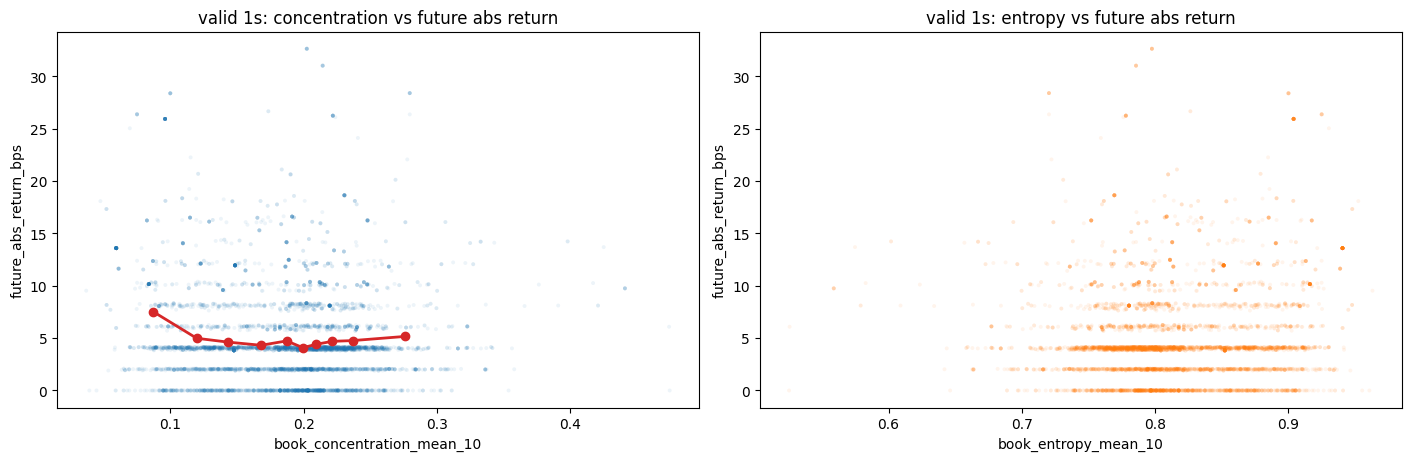

In [6]:
plot_horizon = '1s'
plot_level = 10
plot_frame = get_split_frame(day_records, plot_horizon, 'valid').dropna(
    subset=[f'book_concentration_mean_{plot_level}', 'future_abs_return_bps']
).copy()

plot_frame['concentration_bucket'] = pd.qcut(
    plot_frame[f'book_concentration_mean_{plot_level}'],
    10,
    labels=False,
    duplicates='drop',
) + 1

bucket_df = (
    plot_frame.groupby('concentration_bucket', as_index=False)
    .agg(
        n=('future_abs_return_bps', 'size'),
        mean_concentration=(f'book_concentration_mean_{plot_level}', 'mean'),
        mean_entropy=(f'book_entropy_mean_{plot_level}', 'mean'),
        mean_effective_levels=(f'book_effective_levels_mean_{plot_level}', 'mean'),
        mean_abs_return_bps=('future_abs_return_bps', 'mean'),
    )
    .sort_values('concentration_bucket')
    .reset_index(drop=True)
)

display(bucket_df.style.format({
    'mean_concentration': '{:.4f}',
    'mean_entropy': '{:.4f}',
    'mean_effective_levels': '{:.4f}',
    'mean_abs_return_bps': '{:.4f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

ax = axes[0]
ax.scatter(
    plot_frame[f'book_concentration_mean_{plot_level}'],
    plot_frame['future_abs_return_bps'],
    s=8,
    alpha=0.08,
    color='C0',
    edgecolors='none',
    rasterized=True,
)
ax.plot(bucket_df['mean_concentration'], bucket_df['mean_abs_return_bps'], color='C3', linewidth=2.0, marker='o')
ax.set_title(f'valid {plot_horizon}: concentration vs future abs return')
ax.set_xlabel(f'book_concentration_mean_{plot_level}')
ax.set_ylabel('future_abs_return_bps')

ax = axes[1]
ax.scatter(
    plot_frame[f'book_entropy_mean_{plot_level}'],
    plot_frame['future_abs_return_bps'],
    s=8,
    alpha=0.08,
    color='C1',
    edgecolors='none',
    rasterized=True,
)
ax.set_title(f'valid {plot_horizon}: entropy vs future abs return')
ax.set_xlabel(f'book_entropy_mean_{plot_level}')
ax.set_ylabel('future_abs_return_bps')

plt.show()

## Regression Checks

The target here is future absolute return in basis points.
The goal is to see whether concentration is useful on its own and whether it still helps once `flow` and `top` are already present.

In [7]:
MODEL_SPECS = [
    ('concentration_2', ['book_concentration_mean_2']),
    ('concentration_5', ['book_concentration_mean_5']),
    ('concentration_10', ['book_concentration_mean_10']),
    ('hhi_10', ['book_hhi_mean_10']),
    ('touch_share_2_5', ['book_touch_share_2_mean_5']),
    ('touch_share_2_10', ['book_touch_share_2_mean_10']),
    ('touch_share_2_15', ['book_touch_share_2_mean_15']),
    ('flow+top', ['trade_flow_imbalance', 'top_imbalance']),
    ('flow+top+concentration_10', ['trade_flow_imbalance', 'top_imbalance', 'book_concentration_mean_10']),
    ('flow+top+hhi_10', ['trade_flow_imbalance', 'top_imbalance', 'book_hhi_mean_10']),
    ('flow+top+touch_share_2_5', ['trade_flow_imbalance', 'top_imbalance', 'book_touch_share_2_mean_5']),
    ('flow+top+touch_share_2_10', ['trade_flow_imbalance', 'top_imbalance', 'book_touch_share_2_mean_10']),
    ('flow+top+touch_share_2_15', ['trade_flow_imbalance', 'top_imbalance', 'book_touch_share_2_mean_15']),
]

ols_rows = []
for horizon in HORIZONS:
    train = get_split_frame(day_records, horizon, 'train')
    valid = get_split_frame(day_records, horizon, 'valid')
    stress = get_split_frame(day_records, horizon, 'stress')

    for model_name, features in MODEL_SPECS:
        beta = fit_ols_beta(train, features)
        for split_name, base in [('train', train), ('valid', valid), ('stress', stress)]:
            eval_frame, pred = ols_predict(base, features, beta)
            metrics = regression_metrics(eval_frame['future_abs_return_bps'].to_numpy(dtype=float), pred)
            ols_rows.append(
                {
                    'horizon': horizon,
                    'split': split_name,
                    'model': model_name,
                    **metrics,
                }
            )

ols_df = pd.DataFrame(ols_rows).sort_values(['horizon', 'split', 'model']).reset_index(drop=True)
display(ols_df.style.format({
    'r2': '{:.6f}',
    'pearson': '{:.6f}',
    'spearman': '{:.6f}',
    'mae': '{:.4f}',
}))

,horizon,split,model,n,r2,pearson,spearman,mae
0,1s,stress,concentration_10,2119,-0.014158,-0.058726,-0.035110,3.7941
1,1s,stress,concentration_2,2119,-0.006880,0.064832,0.015983,3.8109
2,1s,stress,concentration_5,2119,-0.013888,-0.055847,-0.018412,3.8028
3,1s,stress,flow+top,2110,-0.011712,0.065315,0.038175,3.7945
4,1s,stress,flow+top+concentration_10,2110,-0.012843,0.023872,0.021820,3.7953
5,1s,stress,flow+top+hhi_10,2110,-0.011565,0.070270,0.042150,3.7943
6,1s,stress,flow+top+touch_share_2_10,2110,0.024757,0.222152,0.143900,3.6656
7,1s,stress,flow+top+touch_share_2_15,2110,0.020901,0.221729,0.153567,3.6968
8,1s,stress,flow+top+touch_share_2_5,2110,0.029414,0.234715,0.184177,3.7100
9,1s,stress,hhi_10,2119,-0.012887,0.077921,0.055406,3.7929


## Direction Checks

This section uses the same feature set, but switches the target back to signed `future_return`.
That makes the results closer to the `04_02` flow/book analysis.

The directional score here is the sign match rate between the prediction and the actual signed future return.

In [8]:
DIRECTION_MODEL_SPECS = [
    ('concentration_2', ['book_concentration_mean_2']),
    ('concentration_5', ['book_concentration_mean_5']),
    ('concentration_10', ['book_concentration_mean_10']),
    ('concentration_15', ['book_concentration_mean_15']),
    ('touch_share_2_5', ['book_touch_share_2_mean_5']),
    ('touch_share_2_10', ['book_touch_share_2_mean_10']),
    ('touch_share_2_15', ['book_touch_share_2_mean_15']),
    ('flow+top', ['trade_flow_imbalance', 'top_imbalance']),
    ('flow+top+concentration_10', ['trade_flow_imbalance', 'top_imbalance', 'book_concentration_mean_10']),
    ('flow+top+touch_share_2_5', ['trade_flow_imbalance', 'top_imbalance', 'book_touch_share_2_mean_5']),
    ('flow+top+touch_share_2_10', ['trade_flow_imbalance', 'top_imbalance', 'book_touch_share_2_mean_10']),
    ('flow+top+touch_share_2_15', ['trade_flow_imbalance', 'top_imbalance', 'book_touch_share_2_mean_15']),
]


def direction_metrics(y_true: np.ndarray, pred: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(y_true) & np.isfinite(pred)
    if not mask.any():
        return {'n': 0, 'r2': np.nan, 'pearson': np.nan, 'spearman': np.nan, 'sign_hit_rate': np.nan}
    y = y_true[mask]
    p = pred[mask]
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - p) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    pearson, spearman = safe_corr(y, p)
    sign_hit_rate = float(np.mean(np.sign(y) == np.sign(p)))
    return {'n': int(len(y)), 'r2': float(r2), 'pearson': pearson, 'spearman': spearman, 'sign_hit_rate': sign_hit_rate}


direction_rows = []
for horizon in HORIZONS:
    train = get_split_frame(day_records, horizon, 'train')
    valid = get_split_frame(day_records, horizon, 'valid')
    stress = get_split_frame(day_records, horizon, 'stress')

    for model_name, features in DIRECTION_MODEL_SPECS:
        beta = fit_ols_beta(train, features, target_col='future_return')
        for split_name, base in [('train', train), ('valid', valid), ('stress', stress)]:
            eval_frame, pred = ols_predict(base, features, beta, target_col='future_return')
            metrics = direction_metrics(eval_frame['future_return'].to_numpy(dtype=float), pred)
            direction_rows.append(
                {
                    'horizon': horizon,
                    'split': split_name,
                    'model': model_name,
                    **metrics,
                }
            )

direction_df = pd.DataFrame(direction_rows).sort_values(['horizon', 'split', 'model']).reset_index(drop=True)
display(direction_df.style.format({
    'r2': '{:.6f}',
    'pearson': '{:.6f}',
    'spearman': '{:.6f}',
    'sign_hit_rate': '{:.4f}',
}))

,horizon,split,model,n,r2,pearson,spearman,sign_hit_rate
0,1s,stress,concentration_10,2119,0.000349,0.027862,0.013841,0.3804
1,1s,stress,concentration_15,2119,0.009877,0.117521,0.090101,0.3856
2,1s,stress,concentration_2,2119,-0.002160,-0.029752,-0.051907,0.3539
3,1s,stress,concentration_5,2119,0.009565,0.113265,0.107170,0.4011
4,1s,stress,flow+top,2110,0.091479,0.304030,0.353820,0.5237
5,1s,stress,flow+top+concentration_10,2110,0.091505,0.304069,0.353925,0.5237
6,1s,stress,flow+top+touch_share_2_10,2110,0.088994,0.300517,0.345423,0.5213
7,1s,stress,flow+top+touch_share_2_15,2110,0.092521,0.305771,0.350911,0.5209
8,1s,stress,flow+top+touch_share_2_5,2110,0.089171,0.300183,0.345567,0.5194
9,1s,stress,touch_share_2_10,2119,-0.011365,-0.047349,-0.042517,0.3596


## Conclusion

This notebook is the sweepability-side companion to the flow and impact notebooks.

What to keep if the tables and bucket plots line up the way we expect:

- low entropy / high concentration means liquidity is packed into fewer levels
- high touch-share means liquidity is sitting near the touch rather than spread deeper into the ladder
- concentration is best read as a magnitude or regime feature, not as a standalone directional predictor
- if the additive `flow + top + concentration` models help, keep the concentration feature as a regime modifier

The practical takeaway is simple: use concentration / entropy to identify books that are easier to sweep, then decide whether that regime signal is strong enough to keep in the working set.